In [1]:
%matplotlib inline
import torch
from d2l import torch as d2l

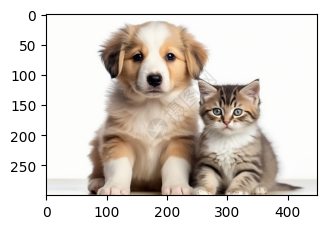

In [2]:
d2l.set_figsize()
img=d2l.plt.imread("C:/Users/高荣轩/Desktop/dog and cat.jpg")
d2l.plt.imshow(img)

In [5]:
def box_corner_to_center(boxes):
    """从（左上，右下）转换到（中间，宽度，高度）"""
    x1,y1,x2,y2=boxes[:,0],boxes[:,1],boxes[:,2],boxes[:,3]
    cx=(x1+x2)/2
    cy=(y1+y2)/2
    w=x2-x1
    h=y2-y1
    boxes=torch.stack((cx,cy,w,h),axis=-1)
    return boxes

def box_center_to_corner(boxes):
    """从（中间，宽度，高度）转换到（左上，右下）"""
    cx,cy,w,h=boxes[:,0],boxes[:,1],boxes[:,2],boxes[:,3]
    x1=cx-0.5*w
    y1=cy-0.5*h
    x2=cx+0.5*w
    y2=cy+0.5*h
    boxes=torch.stack((x1,y1,x2,y2),axis=-1)
    return boxes

In [18]:
dog_bbox,cat_bbox=[85.0,10.0,245.0,295.0],[254.0,100.0,380.0,295.0]
boxes=torch.tensor((dog_bbox,cat_bbox))
box_center_to_corner(box_corner_to_center(boxes))==boxes

tensor([[True, True, True, True],
        [True, True, True, True]])

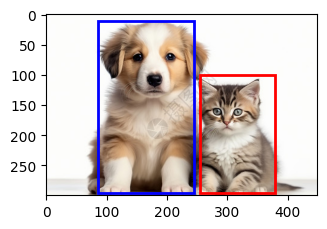

In [19]:
#在图中画出边缘框
def bbox_to_rect(bbox,color):
    return d2l.plt.Rectangle(xy=(bbox[0],bbox[1]),
                             width=bbox[2]-bbox[0],
                             height=bbox[3]-bbox[1],
                             fill=False,
                             edgecolor=color,linewidth=2)

fig=d2l.plt.imshow(img)
fig.axes.add_patch(bbox_to_rect(dog_bbox,'blue'))
fig.axes.add_patch(bbox_to_rect(cat_bbox,'red'))